In [13]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']

import numpy as np
import pandas as pd
import pickle
import pyvista as pv
from mat4py import loadmat
from scipy.stats import boxcox
from scipy.special import inv_boxcox

import jax.numpy as jnp
import jax.random as random
rng = random.PRNGKey(2025)

import seaborn as sns
gt_color = np.array((59, 124, 243))/256
pr_color = np.array((117, 251, 76))/256

In [14]:
with open('data/burgers_step8.pkl', 'rb') as f:
    recipes, ingr_names, calorie_database = pickle.load(f)
n_recipes = len(recipes)
n_ingr = len(ingr_names)

# 1. Mask models

## 1.3. Bit-flip diffusion - works

In [15]:
with open('data/burgers_step8.pkl', 'rb') as f:
    recipes, ingr_names, calorie_database = pickle.load(f)
gt_mask = jnp.array(recipes>0, dtype='int32')
with open('params/bitflip_mask_samples.npy', 'rb') as f:
    samples = pickle.load(f)

### 1.3.1. Some samples for a quick glance

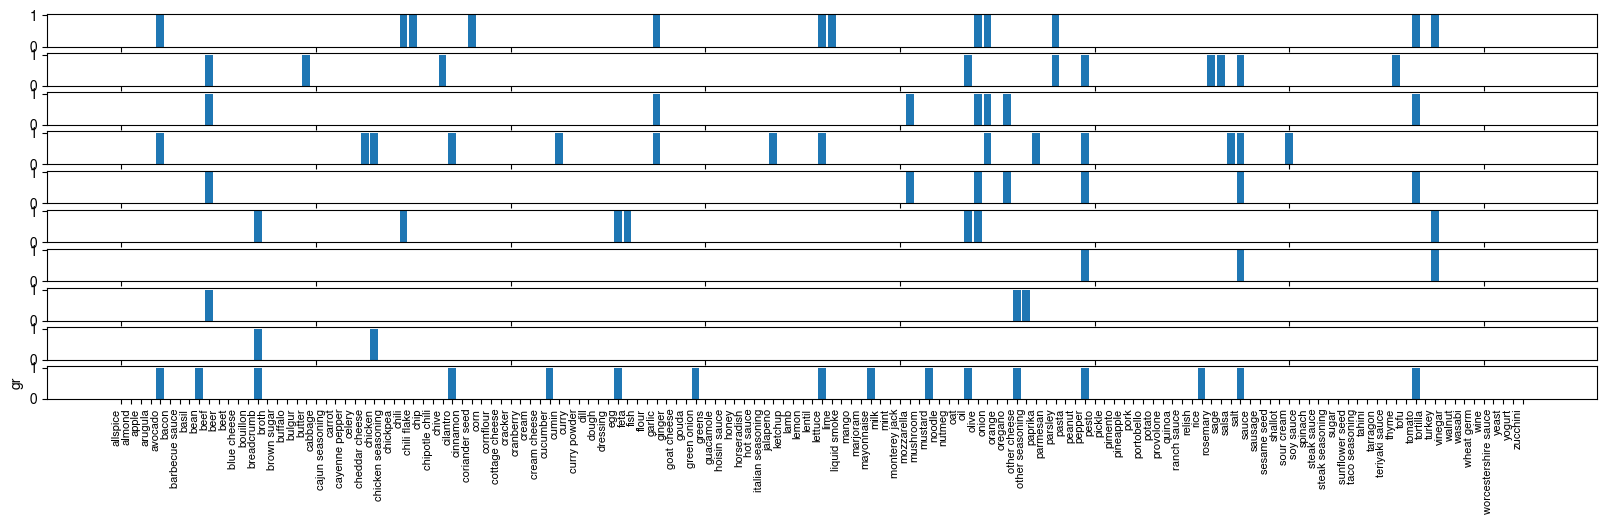

In [16]:
n = 10
plt.figure(figsize=(20,0.5*n))
for i in range(n):
    plt.subplot(n, 1, i+1)
    plt.bar(np.arange(samples.shape[1]), samples[i])

plt.gca().set_xticks(range(len(ingr_names)))
plt.gca().set_xticklabels(ingr_names, rotation=90, ha='right', fontsize=8); 
plt.ylabel('gr'); 

### 1.3.2. Number of ingredients per recipe

In [17]:
print('Average number of ingredients: ')
n_ing_gt = np.mean(gt_mask.sum(axis=1))
n_ing_pr = np.mean(samples.sum(axis=1))
print('Data: ', n_ing_gt)
print('Model: ', n_ing_pr)
print('Relative error: ', np.abs(n_ing_pr-n_ing_gt)/n_ing_gt*100)

Average number of ingredients: 
Data:  8.453901
Model:  9.1445
Relative error:  8.168992


Overlap: 86.51431877566256%


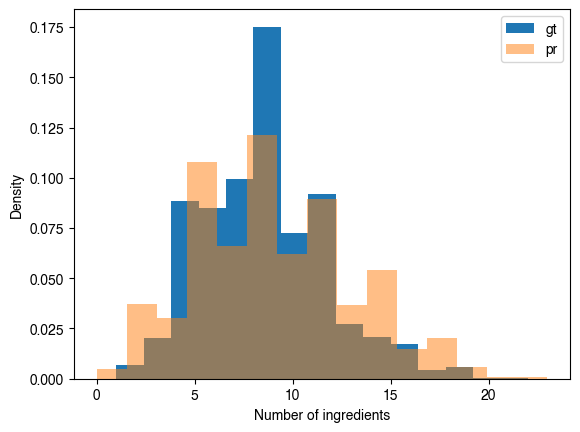

In [18]:
# Distribution of number of ingredients|
def overlap_and_tv(x, y, bins='auto'):
    # histogram-based TV; robust to different sample sizes
    # shared bin edges from pooled data
    hist_range = (min(np.min(x), np.min(y)), max(np.max(x), np.max(y)))
    px, edges = np.histogram(x, bins=bins, range=hist_range, density=True)
    py, _     = np.histogram(y, bins=edges, density=True)
    # convert densities to bin probabilities
    widths = np.diff(edges)
    Px, Py = px*widths, py*widths
    tv = 0.5*np.sum(np.abs(Px - Py))
    ovl = 1 - tv
    return ovl, tv

ovl, tv = overlap_and_tv(gt_mask.sum(axis=1), samples.sum(axis=1))
print(f"Overlap: {ovl*100}%")

plt.hist(gt_mask.sum(axis=1), density=True, label='gt', bins=15)
plt.hist(samples.sum(axis=1), density=True, label='pr', alpha=0.5, bins=15)

plt.xlabel('Number of ingredients')
plt.ylabel('Density')

plt.legend(); 

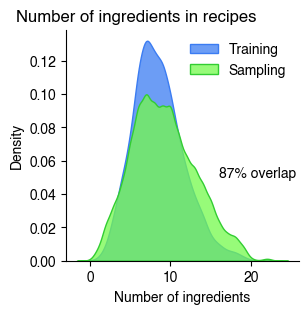

In [19]:
plt.figure(figsize=(3,3))
sns.kdeplot(gt_mask.sum(axis=1), fill=True, color=gt_color, label="Training", alpha=0.75)
sns.kdeplot(samples.sum(axis=1), fill=True, color=pr_color, label="Sampling", alpha=0.75, edgecolor='limegreen')

plt.xlabel('Number of ingredients')
plt.ylabel('Density')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(frameon=False); 
plt.text(x=16, y=0.05, s=f"{ovl*100:.0f}% overlap")
plt.title(f"Number of ingredients in recipes", x=0.3)
plt.savefig("figs/ningr.pdf", bbox_inches='tight')

Maximum absolute difference: 8.65204930305481 %
Maximum relative difference in the top 10: 31.24172019958496 %
Mean absolute error: 1.171280350536108 %


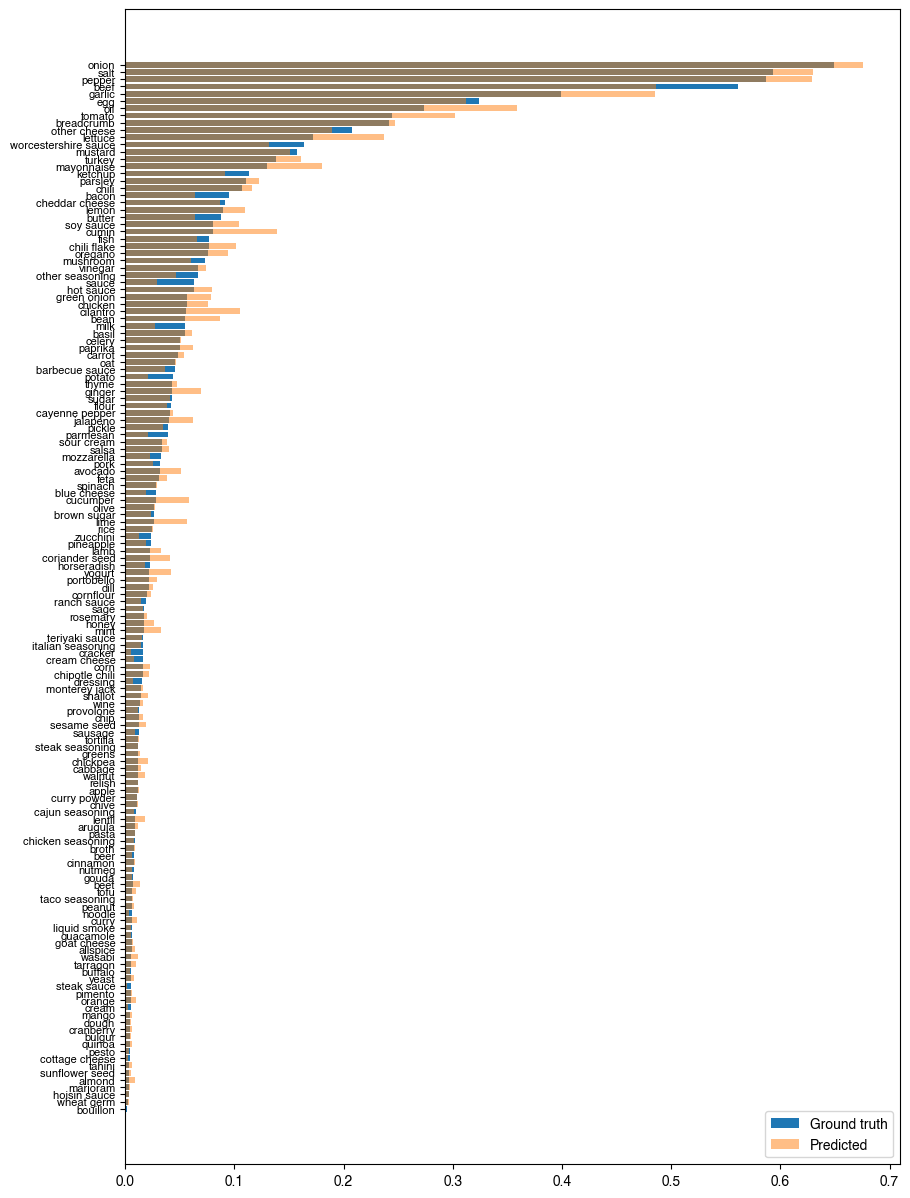

In [20]:
plt.figure(figsize=(10,15))

gt_probs = gt_mask.sum(axis=0)/len(gt_mask)
idx_sorted = np.argsort(gt_probs)
gt_sorted = gt_probs[idx_sorted]
plt.barh(np.arange(gt_mask.shape[1]), gt_sorted, label='Ground truth')

pr_probs = samples.sum(axis=0)/len(samples)
pr_sorted = pr_probs[idx_sorted]
plt.barh(np.arange(gt_mask.shape[1]), pr_sorted, label='Predicted', alpha=0.5)

plt.gca().set_yticks(range(len(ingr_names)))
plt.gca().set_yticklabels(ingr_names[idx_sorted], ha='right', fontsize=8); 
plt.legend(loc='lower right')

max_diff = np.max(np.abs(gt_sorted-pr_sorted))*100
print(f"Maximum absolute difference: {max_diff} %")
print(f"Maximum relative difference in the top 10: {np.max((np.abs(gt_sorted-pr_sorted)/gt_sorted)[-10:])*100} %")


mean_diff = np.mean(np.abs(gt_sorted-pr_sorted))*100
print(f"Mean absolute error: {mean_diff} %")

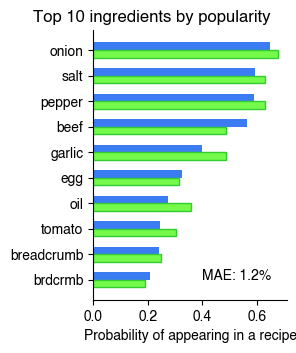

In [21]:
gt_concise = gt_sorted[-10:]
pr_concise = pr_sorted[-10:]
ingr_names_concise = ingr_names[idx_sorted][-10:]
ingr_names_concise[0] = 'brdcrmb'
n = len(gt_concise)

plt.figure(figsize=(2.5,3.5))

bar_width = 0.3  # width of each bar
y_pos = np.arange(n)  # original y positions

# Shift the bars so they are adjacent
plt.barh(y_pos + bar_width/2, gt_concise, height=bar_width, label='Train. data', color=gt_color)
plt.barh(y_pos - bar_width/2, pr_concise, height=bar_width, label='Samples', color=pr_color, edgecolor='limegreen')

plt.gca().set_yticks(y_pos)
plt.gca().set_yticklabels(ingr_names_concise, ha='right')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.legend(loc='lower right', frameon=False)
plt.xlabel('Probability of appearing in a recipe')
# plt.ylabel('Top 10 ingredients by popularity')
# plt.title(f'Mean absolute error: {mean_diff:.1f}%', x=0.2)
plt.title('Top 10 ingredients by popularity', x=0.3)
plt.text(x=0.4, y=0, s=f'MAE: {mean_diff:.1f}%')
plt.savefig('figs/prob_appearing.pdf', bbox_inches='tight')

### 1.3.3. Conditional probabilities

In [22]:
gt_correlation_matrix = np.corrcoef(gt_mask, rowvar=False)
pr_correlation_matrix = np.corrcoef(samples, rowvar=False)

# Sort by most highly correlated pairs
pairs = []
n = gt_correlation_matrix.shape[0]
for i in range(n):
    for j in range(i+1, n):  # j>i to avoid duplicates and diagonal
        corr_value = gt_correlation_matrix[i, j]
        pairs.append((i, j, corr_value))
pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

print("Most positively and most negatively correlated items")
top_and_bottom = pairs_sorted[:10] + pairs_sorted[-10:]
print(f"{'i':<5} {'j':<5} {'ingr_i':<20} {'ingr_j':<20} {'correlation (gt)':<10} {'correlation (pr)':<10}")
print("-"*70)
for i,j,corr in top_and_bottom:
    print(f"{i:<5} {j:<5} {ingr_names[i]:<20} {ingr_names[j]:<20} {corr:<10.4f} {pr_correlation_matrix[i,j]:<10.4f}")

Most positively and most negatively correlated items
i     j     ingr_i               ingr_j               correlation (gt) correlation (pr)
----------------------------------------------------------------------
99    115   pepper               salt                 0.5556     0.6381    
72    133   lettuce              tomato               0.4990     0.5639    
56    121   ginger               soy sauce            0.4692     0.5687    
14    51    breadcrumb           egg                  0.4384     0.5484    
69    79    lamb                 mint                 0.4229     0.5436    
0     35    allspice             cinnamon             0.4224     0.4486    
44    143   cucumber             yogurt               0.4071     0.3955    
103   130   pineapple            teriyaki sauce       0.3631     0.3316    
52    69    feta                 lamb                 0.3361     0.4032    
34    45    cilantro             cumin                0.3285     0.3212    
93    115   other seasoning 

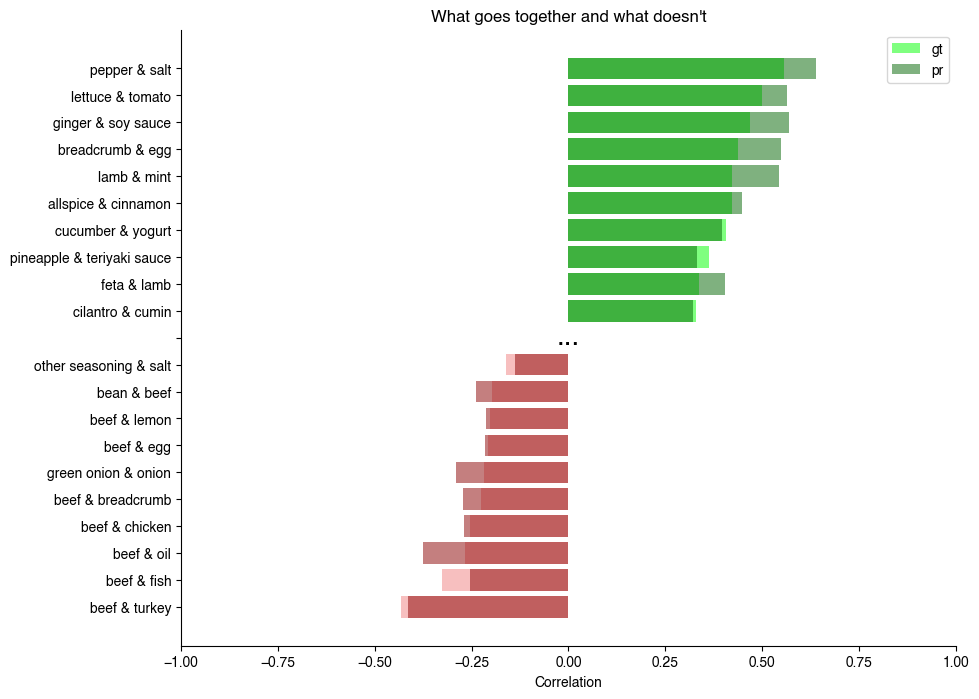

In [23]:
top_5 = pairs_sorted[:10]
bottom_5 = pairs_sorted[-10:]

top_labels = [f"{ingr_names[p[0]]} & {ingr_names[p[1]]}" for p in top_5]
top_values_gt = [p[2] for p in top_5]
top_values_pr = [pr_correlation_matrix[i,j] for i,j,_ in top_5]

bottom_labels = [f"{ingr_names[p[0]]} & {ingr_names[p[1]]}" for p in bottom_5]
bottom_values_gt = [p[2] for p in bottom_5]
bottom_values_pr = [pr_correlation_matrix[i,j] for i,j,_ in bottom_5]

combined_labels = top_labels + [' '] + bottom_labels

fig, ax = plt.subplots(figsize=(10, 8))

# Bars for top 5
ax.barh(range(len(top_labels)), top_values_gt, color='lime', label = 'gt', alpha=0.5)
ax.barh(range(len(top_labels)), top_values_pr, color='darkgreen', label = 'pr', alpha=0.5)
# Bars for bottom 5, offset by len(top_labels) + 1 (for ellipsis)
ax.barh(range(len(top_labels) + 1, len(top_labels) + 1 + len(bottom_labels)), bottom_values_gt, color='lightcoral', alpha=0.5)
ax.barh(range(len(top_labels) + 1, len(top_labels) + 1 + len(bottom_labels)), bottom_values_pr, color='darkred', alpha=0.5)

# Set yticks with combined labels, placing empty label for ellipsis position
yticks_pos = list(range(len(combined_labels)))
yticks_labels = combined_labels.copy()
ax.set_yticks(yticks_pos)
ax.set_yticklabels(yticks_labels)

# Add ellipsis text between groups
ax.text(0.0, len(top_labels), '...', fontsize=20, ha='center', va='center')

# Axis labels and title
ax.set_xlabel('Correlation')
ax.set_xlim(-1, 1)
ax.invert_yaxis()  # So highest correlation is at top

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend()

plt.title('What goes together and what doesn\'t'); 

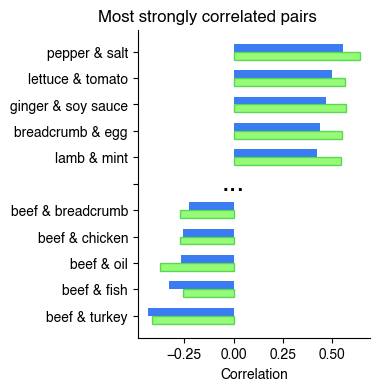

In [24]:
top_5 = pairs_sorted[:5]
bottom_5 = pairs_sorted[-5:]

top_labels = [f"{ingr_names[p[0]]} & {ingr_names[p[1]]}" for p in top_5]
top_values_gt = [p[2] for p in top_5]
top_values_pr = [pr_correlation_matrix[i,j] for i,j,_ in top_5]

bottom_labels = [f"{ingr_names[p[0]]} & {ingr_names[p[1]]}" for p in bottom_5]
bottom_values_gt = [p[2] for p in bottom_5]
bottom_values_pr = [pr_correlation_matrix[i,j] for i,j,_ in bottom_5]

combined_labels = top_labels + [' '] + bottom_labels

fig, ax = plt.subplots(figsize=(3, 4))


# Bars for top 5
n = len(top_labels)
bar_width = 0.3  # width of each bar
y_pos = np.arange(n)  # original y positions
ax.barh(y_pos - bar_width/2, top_values_gt, height=bar_width, color=gt_color, label = 'Train. data', )
ax.barh(y_pos + bar_width/2, top_values_pr, height=bar_width, color=pr_color, edgecolor='limegreen', label = 'Samples', alpha=0.75)

# Bars for bottom 5, offset by len(top_labels) + 1 (for ellipsis)
y_pos = np.arange(len(top_labels) + 1, len(top_labels) + 1 + len(bottom_labels))  # original y positions
ax.barh(y_pos - bar_width/2, bottom_values_gt, height=bar_width, color=gt_color)
ax.barh(y_pos + bar_width/2, bottom_values_pr, height=bar_width, color=pr_color, edgecolor='limegreen', alpha=0.75)

# Set yticks with combined labels, placing empty label for ellipsis position
yticks_pos = list(range(len(combined_labels)))
yticks_labels = combined_labels.copy()
ax.set_yticks(yticks_pos)
ax.set_yticklabels(yticks_labels)

# Add ellipsis text between groups
ax.text(0.0, len(top_labels), '...', fontsize=20, ha='center', va='center')

# Axis labels and title
ax.set_xlabel('Correlation')
# ax.set_xlim(-1, 1)
ax.invert_yaxis()  # So highest correlation is at top

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# ax.legend(frameon=False)

plt.title('Most strongly correlated pairs', x=0.3); 
plt.savefig('figs/correlation_pairs.pdf', bbox_inches='tight')

# 2. Value models

## 2.1. Diffusion

In [25]:
from train_diffusion_val import *
rng = random.PRNGKey(2026)

with open('data/burgers_step8.pkl', 'rb') as f:
    recipes, ingr_names, calorie_database = pickle.load(f)
n_recipes = len(recipes)
n_ingr = len(ingr_names)
gt_mask = jnp.array(recipes>0, dtype='int32')

with open(f'params/diff_value_params.npy', 'rb') as f:
    params, fitted_lambdas, means_stds, train_data, val_data = pickle.load(f)

# with open(f'params/diff_value_samples.npy', 'rb') as f:
#     samples = pickle.load(f)

val_vals, val_mask = val_data
val_mask = jnp.array(val_mask, dtype='int32')
score_model = ApproximateScore(n_hidden=n_hidden)
trained_score = lambda x, t, mask: score_model.apply(params, x, t, mask)
samples = reverse_sde(rng, n_ingr, drift, dispersion, trained_score, val_mask).block_until_ready()


unnormalized_pr = []
unnormalized_gt = []
for i in range(n_ingr):
    ingr, fitted_lambda, (mean, std) = samples[:,i], fitted_lambdas[i], means_stds[i]
    ingr = ingr*std + mean
    ingr = inv_boxcox(ingr, fitted_lambda)
    unnormalized_pr.append(ingr)

    ingr = val_vals[:,i]
    ingr = ingr*std + mean
    ingr = inv_boxcox(ingr, fitted_lambda)
    unnormalized_gt.append(ingr)
unnormalized_pr = np.array(unnormalized_pr).T * val_mask
unnormalized_gt = np.array(unnormalized_gt).T

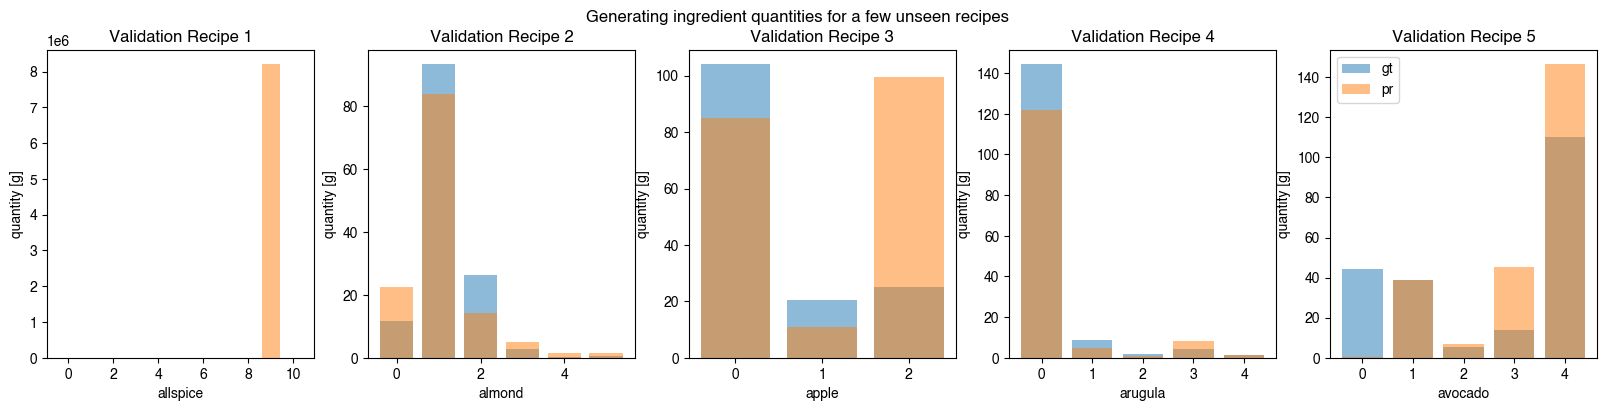

In [26]:
plt.figure(figsize=(20,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.title(f'Validation Recipe {i+1}')
    xs = np.arange(sum(val_mask[i]))
    y_idx = val_mask[i]>0
    plt.bar(xs, unnormalized_gt[i,y_idx], alpha = 0.5, label = 'gt')
    plt.bar(xs, unnormalized_pr[i,y_idx], alpha = 0.5, label = 'pr')

    plt.xlabel(ingr_names[i])
    plt.ylabel('quantity [g]')

plt.suptitle('Generating ingredient quantities for a few unseen recipes'); 
plt.legend()

## Distributions of the quantities

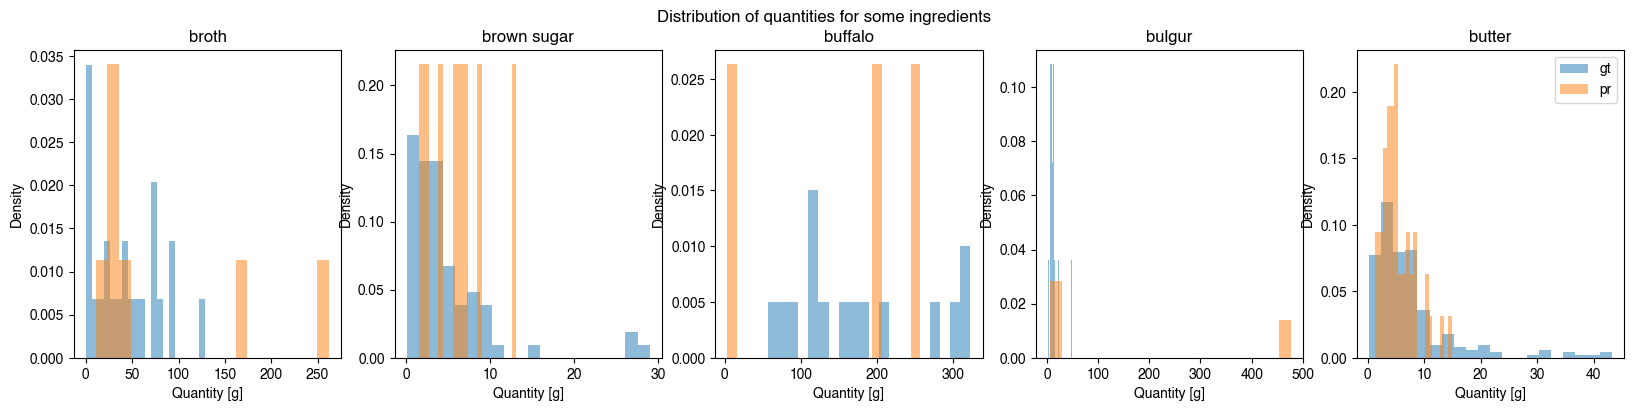

In [27]:
plt.figure(figsize=(20,4))

i_panel = 0
for i_ingr in [15, 16,17,18,19]:
    plt.subplot(1,5,i_panel+1)
    i_panel+= 1
    # plt.hist(unnormalized_gt[unnormalized_gt[:,i_ingr]>0, i_ingr], bins=20, label='gt', density=True, alpha=0.5); 
    plt.hist(recipes[recipes[:,i_ingr]>0, i_ingr], bins=20, label='gt', density=True, alpha=0.5)
    plt.hist(unnormalized_pr[unnormalized_pr[:,i_ingr]>0, i_ingr], bins=20, label='pr', density=True, alpha=0.5); 

    plt.xlabel('Quantity [g]')
    plt.ylabel('Density')
    plt.title(ingr_names[i_ingr])

plt.suptitle('Distribution of quantities for some ingredients')
plt.legend()


In [28]:
gt_qty = []
pr_qty = []
for i in range(samples.shape[1]):
    temp = recipes[:,i]
    temp = temp[temp>0]
    gt_qty.append(np.mean(temp))

    temp = unnormalized_pr[:,i]
    temp = temp[temp>0]
    pr_qty.append(np.mean(temp))
gt_qty = np.array(gt_qty)
pr_qty = np.array(pr_qty)
pr_qty = np.nan_to_num(pr_qty, nan=0)

idx_sorted = np.argsort(gt_qty)
gt_sorted = gt_qty[idx_sorted]
pr_sorted = pr_qty[idx_sorted]

gt_concise = gt_sorted[-10:]
pr_concise = pr_sorted[-10:]
n = len(gt_concise)

In [37]:
mean_diff = np.mean(np.abs(gt_sorted[-10:]-pr_sorted[-10:]))

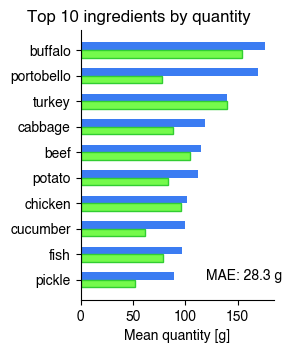

In [38]:
plt.figure(figsize=(2.5,3.5))
# plt.barh(np.arange(n), gt_concise, label='Ground truth', color=gt_color)
# plt.barh(np.arange(n), pr_concise, label='Predicted', alpha=0.75, color=pr_color, edgecolor='limegreen')

bar_width = 0.3  # width of each bar
y_pos = np.arange(n)  # original y positions
plt.barh(y_pos + bar_width/2, gt_concise, height=bar_width, label='Train. data', color=gt_color)
plt.barh(y_pos - bar_width/2, pr_concise, height=bar_width, label='Samples', color=pr_color, edgecolor='limegreen')

plt.gca().set_yticks(range(n))
plt.gca().set_yticklabels(ingr_names[idx_sorted][-10:], ha='right'); 
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.legend(loc='lower right', frameon=False)
plt.xlabel('Mean quantity [g]')
# plt.ylabel('Top 10 ingredients by quantity')
# plt.title(f'Mean absolute error: {mean_diff:.1f} g', x=0.2)
plt.title('Top 10 ingredients by quantity', x=0.3)
plt.text(x=120, y=0, s=f'MAE: {mean_diff:.1f} g')
plt.savefig('figs/mean_qty.pdf', bbox_inches='tight')